In [2]:
import numpy as np
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [3]:
positions = np.linspace(0, 60, 9)   # 9 nodes from 0 to 60 m
nodes = [n.nodes(pos, 0, 0) for pos in positions]

In [4]:
# material parameters
# define element parameters
E=210e9 #Pa
nu = 0.3 #Poisson's ratio

G = E/(2*(1+nu)) #Pa
m = 5596024 #kg # From BMK report Maeslantering
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.016 #m
t2 = 0.06   #0.1125 #m
L_truss_element_y = 15 #m
h_truss = 18 #m

Ieqy = 300
Ieqz = 0.3 * Ieqy
b_eq  = ((Ieqz**3) / (Ieqy* (1/12)**2))**(1/8)
h_eq = Ieqz / ((1/12)* b_eq**3)
A1 = np.pi * (d1/2)**2 - np.pi * ((d1/2) - 2 * t1)**2
A2 = np.pi * (d2/2)**2 - np.pi * ((d2/2) - 2 * t2)**2
Aeq = A1 * 5 + A2 * 3

L = 234
# rho = m / (L * b_eq * h_eq) 
rho = m / (L * Aeq)
# rho = 7850  * 0.75
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.042
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho, Aeq, Ieqy, Ieqz, Ip]
print("Effective area: ", Aeq)
print("Effective moment of inertia about y-axis: ", Ieqy)
print("Effective moment of inertia about z-axis: ", Ieqz)
print("Effective torsional constant: ", It)
print("Effective height: ", h_eq)
print("Effective width: ", b_eq)
print("Density: ", rho)



Effective area:  2.286074142164221
Effective moment of inertia about y-axis:  300
Effective moment of inertia about z-axis:  90.0
Effective torsional constant:  46.10585514915944
Effective height:  9.003999627300194
Effective width:  4.931693703640426
Density:  10461.004758136389


In [5]:
num_nodes = 9

elements = [e.elements(nodes[i], nodes[i+1], ep_K, ep_m) 
            for i in range(num_nodes - 1)]

element_nodes = [[i+1, i+2] 
                 for i in range(num_nodes - 1)]

dofs = n.degrees_of_freedom(nodes)
element_locs = []


for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))

N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)

indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_9'][0:3]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]


eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:15])


eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_full.shape)

eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_disp_full.shape


# Extract rotations the same way you did for displacements
eigvecs_rot_full = e.extract_rotation(eigvecs_full, keep=3, skip=3)
print(eigvecs_rot_full.shape)  # (n_nodes*3, n_modes)

,Frequency (Hz),Frequency (rad/s)
0,5.285495,33.209745
1,5.470430,34.371728
2,7.903948,49.661967
3,8.012859,50.346277
4,8.908477,55.973610
5,9.348889,58.740803
6,9.566518,60.108205
7,9.680096,60.821837
8,9.736023,61.173237
9,10.397244,65.327808


Expanded eigenvectors shape: (54, 47)
(27, 47)


In [6]:

#First ten modes
modes_to_plot = 5
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3) + nodes)



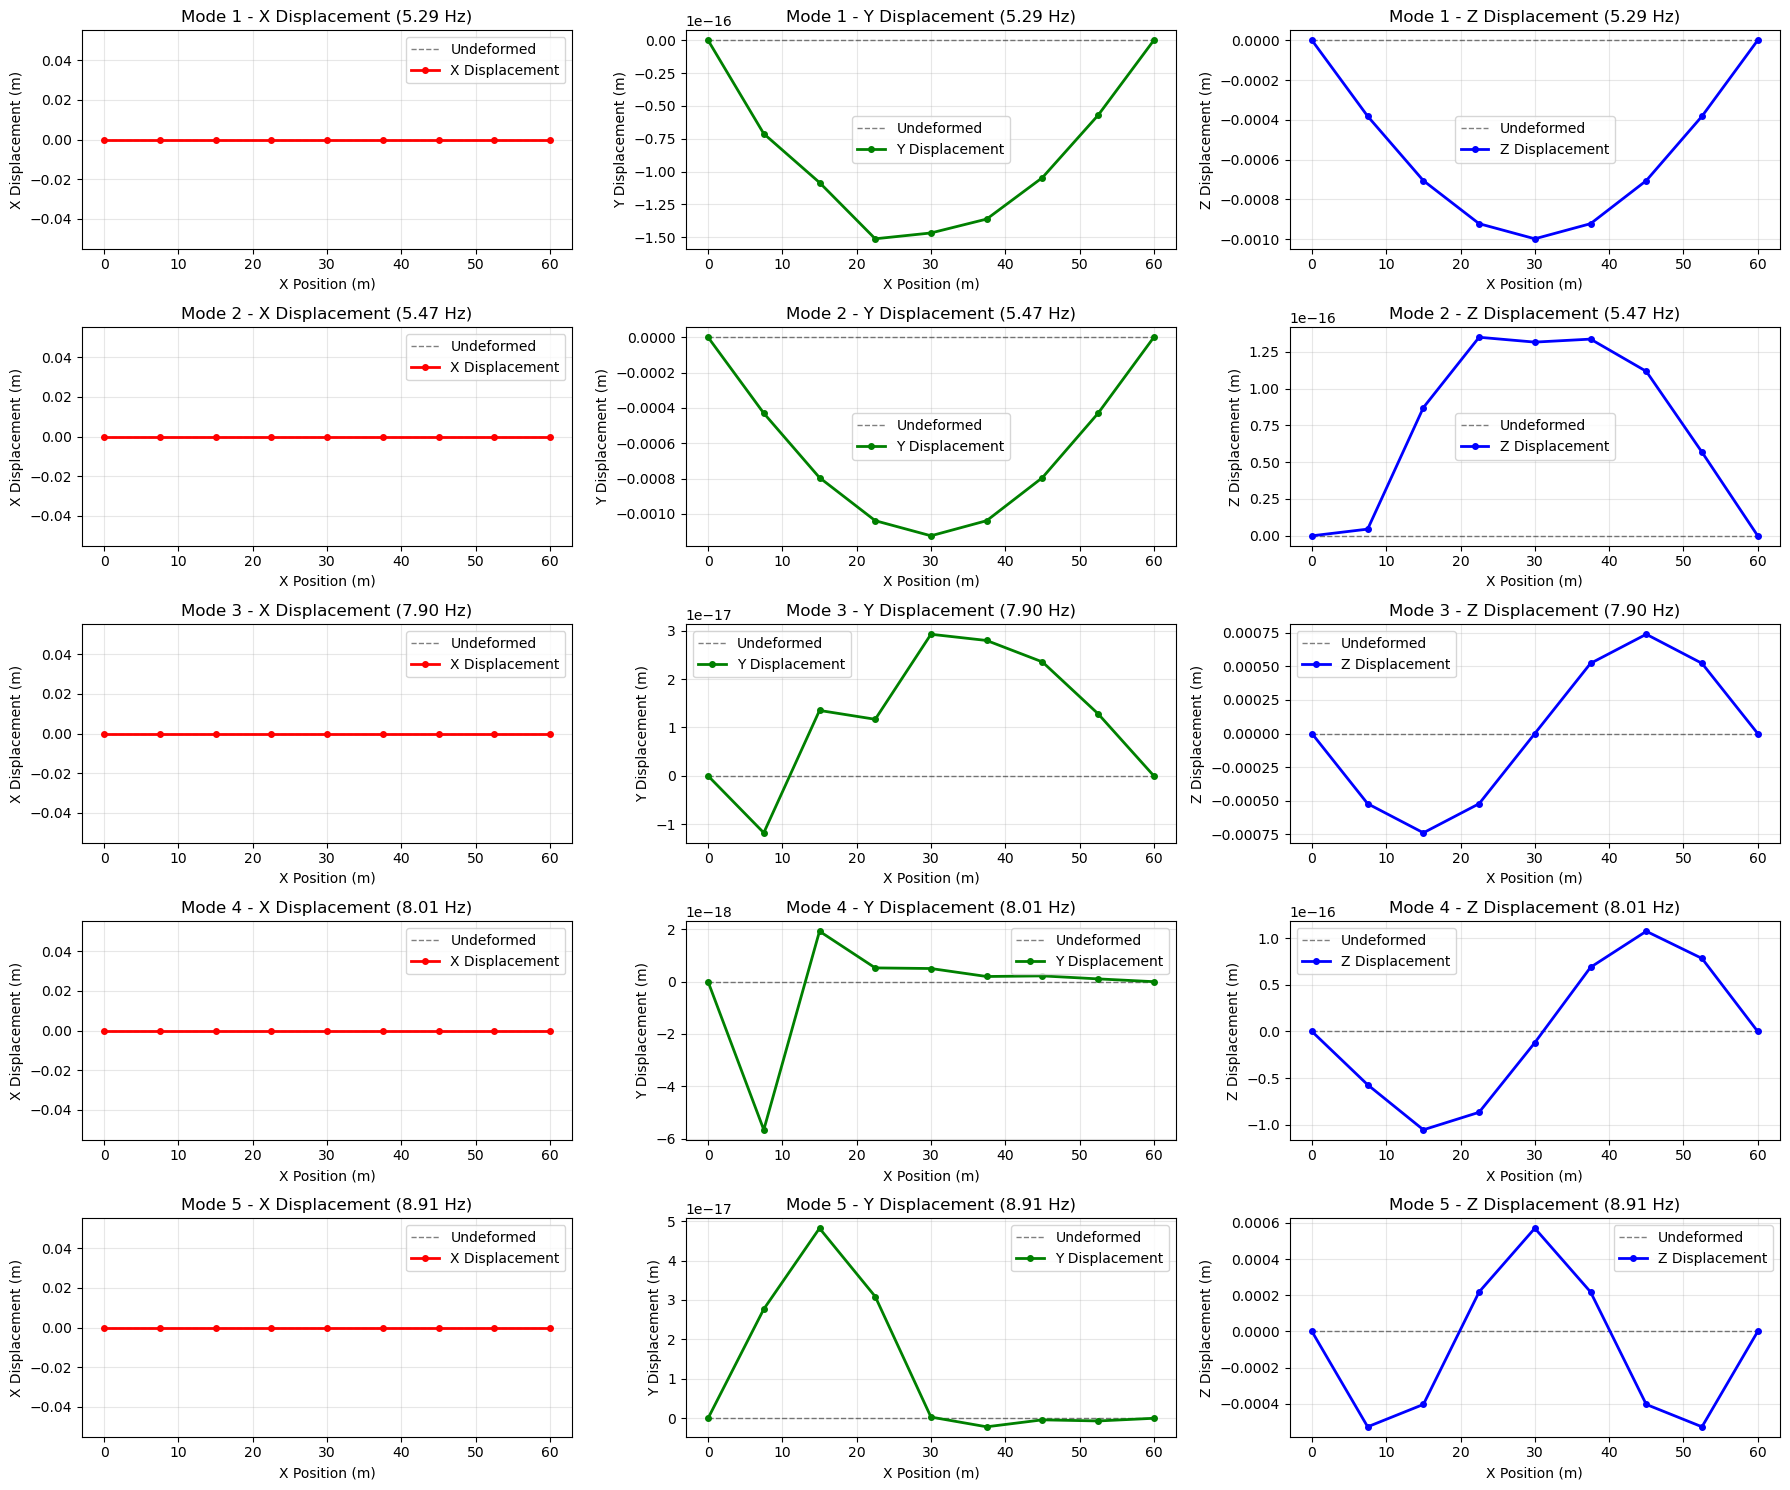

In [7]:
fig, axes = plt.subplots(modes_to_plot, 3, figsize=(18, 3*modes_to_plot))

for i in range(modes_to_plot):
    # X displacement
    ax_x = axes[i, 0] if modes_to_plot > 1 else axes[0]
    x_undeformed = [node[0] for node in nodes]
    x_deformed = modes[i][:, 0]
    ax_x.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_x.plot(x_undeformed, x_deformed - x_undeformed, 'r-', linewidth=2, label='X Displacement', marker='o', markersize=4)
    ax_x.set_xlabel('X Position (m)')
    ax_x.set_ylabel('X Displacement (m)')
    ax_x.set_title(f'Mode {i+1} - X Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_x.grid(True, alpha=0.3)
    ax_x.legend()
    
    # Y displacement
    ax_y = axes[i, 1] if modes_to_plot > 1 else axes[1]
    y_deformed = modes[i][:, 1]
    ax_y.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_y.plot(x_undeformed, y_deformed, 'g-', linewidth=2, label='Y Displacement', marker='o', markersize=4)
    ax_y.set_xlabel('X Position (m)')
    ax_y.set_ylabel('Y Displacement (m)')
    ax_y.set_title(f'Mode {i+1} - Y Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_y.grid(True, alpha=0.3)
    ax_y.legend()
    
    # Z displacement
    ax_z = axes[i, 2] if modes_to_plot > 1 else axes[2]
    z_undeformed = [node[2] for node in nodes]
    z_deformed = modes[i][:, 2]
    ax_z.plot(x_undeformed, z_undeformed, 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_z.plot(x_undeformed, z_deformed, 'b-', linewidth=2, label='Z Displacement', marker='o', markersize=4)
    ax_z.set_xlabel('X Position (m)')
    ax_z.set_ylabel('Z Displacement (m)')
    ax_z.set_title(f'Mode {i+1} - Z Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_z.grid(True, alpha=0.3)
    ax_z.legend()

plt.tight_layout()
plt.show()

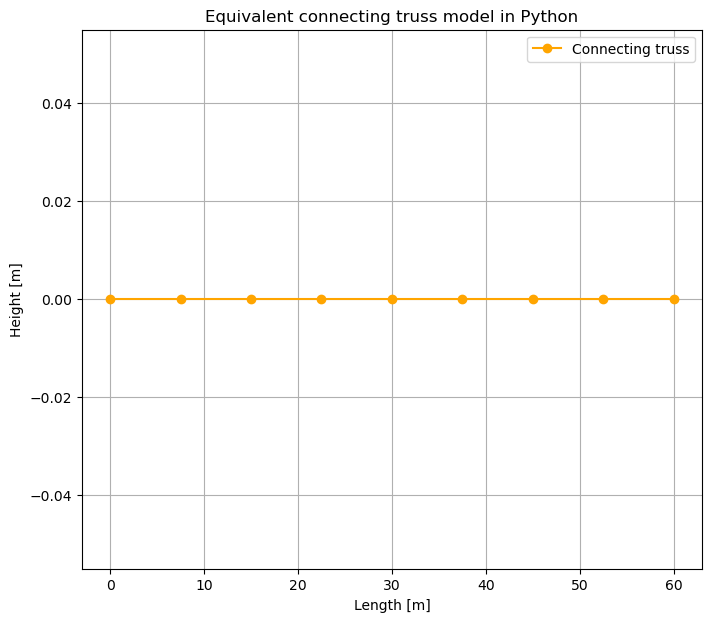

In [14]:
import matplotlib.pyplot as plt

# Example assumption: nodes is a list like [(x1, y1), (x2, y2), ...]
# If your structure is different, tell me and I’ll adapt it.

plt.figure(figsize=(8, 7))
plt.grid(True)

plt.xlabel('Length [m]')
plt.ylabel('Height [m]')
plt.title('Equivalent connecting truss model in Python')

# Extract coordinates
x_vals = [node[0] for node in nodes]
y_vals = [node[1] for node in nodes]  # in case you later extend to 2D

# Plot connected nodes with markers
plt.plot(x_vals, y_vals, '-o', color='orange', label='Connecting truss')
plt.legend()
plt.savefig('connecting_truss_model.png', dpi=600, bbox_inches='tight')
plt.show()